# <div align="center"><u>The low mutual info dependency dataset</u>

## - General description of the low mutual info dependency dataset:
    
The following implementation applies a low mutual info dependency filter to the Colon-Kidney dataset, where the dimensionality ranges between 55 and 110 features (gene expressions).

##############################################################################################################################

###  Import some useful libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import random
from sklearn import metrics

from sklearn.feature_selection import mutual_info_classif

import time

### Suppress warnings

In [2]:
# import warnings

# # To suppress all warnings
# warnings.filterwarnings("ignore")

### Start time

In [3]:
# Start time
start_time = time.time()

### Load the final colon-kidney dataset and store it within a pandas DataFrame

In [4]:
# Load the dataset and store it withina  panda dataframe to handle it easier
df = pd.read_csv(r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\The colon-kidney final dataset.csv")

# Print the dataset
df

,1007_s_at,121_at,1405_i_at,1438_at,1487_at,1494_f_at,1552256_a_at,1552257_a_at,1552274_at,1552275_s_at,...,AFFX-r2-Ec-bioC-5_at,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,Target,Tissue
0,2883.2,2109.1,702.0,114.4,822.2,235.1,3346.1,815.1,233.3,218.4,...,1908.1,30396.7,28371.7,85830.1,57084.9,3651.2,1736.1,2411.6,0,Kidney
1,2607.4,1204.2,228.0,19.2,1497.1,167.6,23003.6,948.6,414.1,124.1,...,3012.0,16748.8,13581.2,53322.5,37139.5,1648.1,502.9,890.6,0,Kidney
2,2736.8,3912.2,1020.8,39.0,574.9,448.9,1337.9,605.6,176.8,411.9,...,14835.5,64597.8,59311.2,203060.6,146422.6,3346.4,673.2,1499.3,0,Kidney
3,1471.6,1318.2,4564.6,9.4,1426.5,105.2,2594.3,929.8,240.4,139.0,...,11300.8,58551.7,49073.6,119460.8,95682.3,2553.5,961.2,1468.4,0,Kidney
4,3564.7,2535.6,944.1,40.0,734.2,651.0,1490.5,712.3,632.7,185.0,...,12966.9,54572.5,51049.1,178178.2,129533.2,3399.1,1209.8,1981.6,0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,3197.8,713.4,191.1,747.0,1597.8,179.5,1717.2,2261.2,305.5,181.8,...,1494.9,22165.4,20442.0,65246.8,46710.2,2057.3,810.0,1338.2,1,Colon
542,2161.9,1244.3,2347.0,1995.6,697.8,194.6,508.4,1042.5,729.7,537.2,...,4588.2,21225.6,20067.2,80607.7,60204.9,1116.3,432.8,744.5,1,Colon
543,4105.2,664.4,445.2,7008.2,1887.0,204.0,1951.8,2540.1,259.2,239.5,...,1318.0,19659.4,15774.8,56065.6,43347.8,1191.2,371.3,688.5,1,Colon
544,4204.7,894.2,102.8,1374.8,2891.5,306.2,1397.9,2072.4,474.0,316.3,...,6375.2,34393.5,29137.7,89215.2,71290.1,1878.7,1009.7,1126.6,1,Colon


### Separate the features (X) and target (y)

In [5]:
# Drop the last two columns
X = df.iloc[:, :-2]  # Keep all columns except the last 2
y = df.iloc[:, -2]   # Second to last column is "Target"

### Compute Mutual Information scores for each feature

In [6]:
# Compute the Mutual Info
mi_scores = mutual_info_classif(X, y)

### Plot the MI

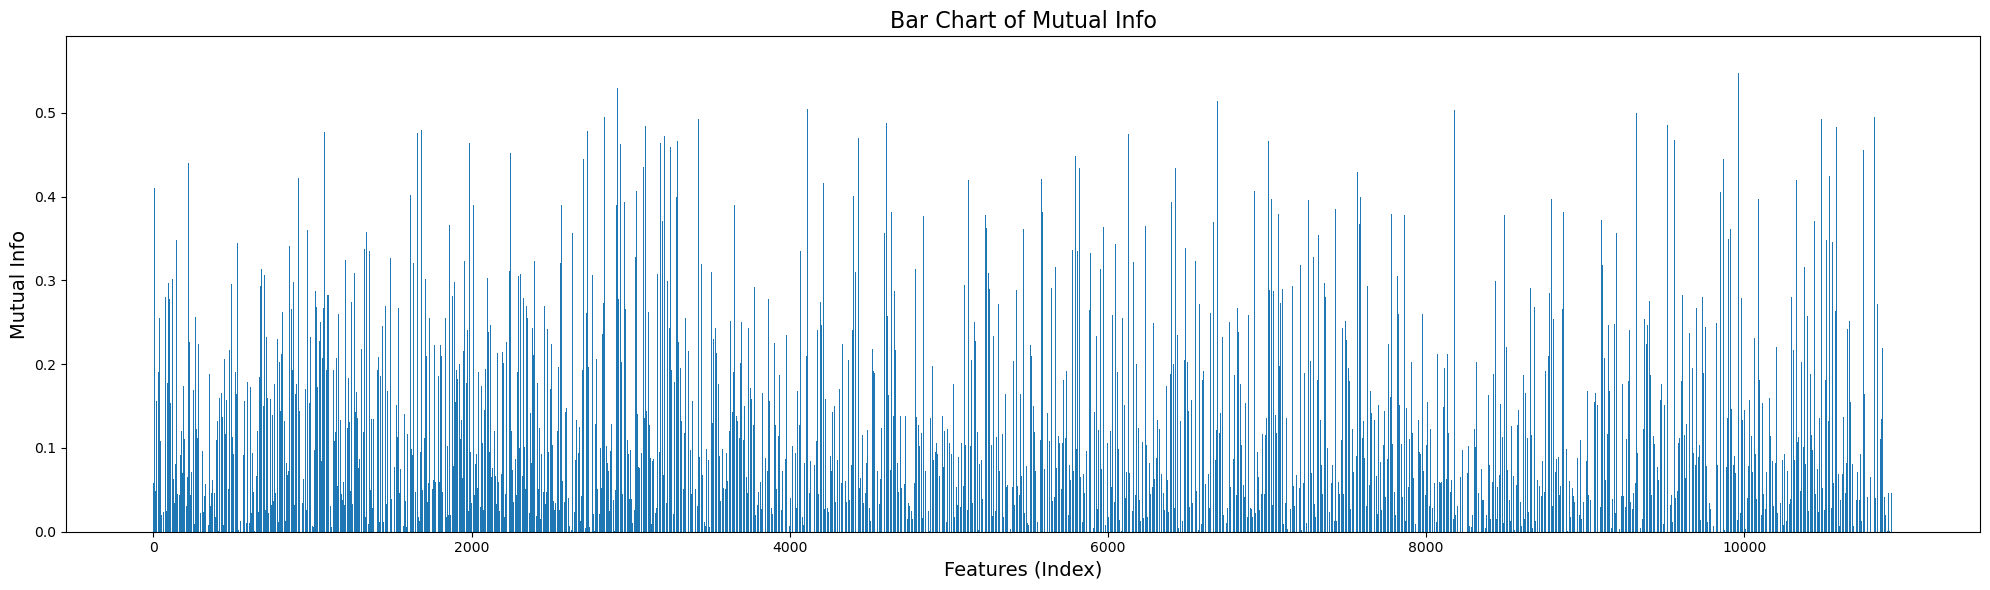

In [7]:
# Create a figure for the bar chart
plt.figure(figsize=(20, 6))

# Create the bar chart
plt.bar(range(len(mi_scores)), mi_scores)  # Use simple range instead of feature names

# Set labels and title
plt.xlabel("Features (Index)", fontsize=14)
plt.ylabel("Mutual Info", fontsize=14)
plt.title("Bar Chart of Mutual Info", fontsize=16)

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

### Set a threshold for selecting important features (target -> 55-110)

In [8]:
threshold = 0.485  # Adjust this value

### ### Create a dataframe with the remaining features

In [9]:
# Select the important features
selected_features = np.where(mi_scores > threshold)[0]

# Create a new DataFrame with the selected features
x_selected = df.iloc[:, :-2].iloc[:, selected_features]

# Add 'Target' and 'Tissue' columns back to this new DataFrame
df_selected = x_selected.copy()
df_selected['Target'] = df['Target']
df_selected['Tissue'] = df['Tissue']

# Assign the filtered DataFrame to df (rename it)
df = df_selected

df

,201839_s_at,201848_s_at,201849_at,201884_at,202489_s_at,202831_at,202870_s_at,203108_at,203397_s_at,203757_s_at,...,237058_x_at,237328_at,238441_at,239093_at,33322_i_at,40284_at,46323_at,60474_at,Target,Tissue
0,2673.6,7551.4,20023.9,271.3,69.4,185.5,97.6,28.5,843.9,198.1,...,4078.2,4247.6,1726.2,612.7,795.4,54.1,559.0,138.3,0,Kidney
1,5603.1,4987.4,15447.1,73.2,1199.8,1254.3,671.8,397.6,79.2,71.0,...,18.0,358.5,863.7,280.5,4011.9,770.5,1844.9,76.8,0,Kidney
2,2016.8,2635.0,8506.7,245.1,306.0,207.5,63.6,419.3,282.9,167.1,...,6551.1,1991.8,900.1,362.3,770.2,15.2,802.0,352.0,0,Kidney
3,401.3,3331.9,10716.2,136.3,15.5,281.0,108.0,468.0,220.1,51.7,...,2311.4,1071.4,614.4,245.3,477.7,13.1,1069.0,60.3,0,Kidney
4,5045.3,2091.8,5790.8,423.8,355.3,456.5,157.5,1167.2,996.8,477.2,...,4399.8,2080.2,801.7,411.5,1162.1,25.1,685.1,473.9,0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,38202.0,1149.6,2950.5,57575.6,11975.9,11688.1,1207.6,5586.5,5284.8,37521.2,...,48.0,8.8,71.3,106.1,12544.7,1365.6,3093.4,4633.0,1,Colon
542,25593.3,405.5,681.6,37803.5,2799.2,8380.9,1011.4,4235.9,2337.9,515.7,...,539.2,29.3,50.1,73.8,13263.8,848.8,1626.6,3180.5,1,Colon
543,29192.2,126.0,156.9,34074.5,6467.3,21643.5,1229.5,2070.4,4949.0,10920.4,...,80.6,35.5,78.6,168.4,9710.7,1194.9,3002.3,7073.1,1,Colon
544,52006.4,244.3,325.1,80572.0,19750.3,24972.2,955.4,5289.0,5266.1,41795.5,...,124.4,30.5,640.2,168.9,13382.2,951.9,3832.2,12160.2,1,Colon


### Export the low mutual info filtered dataset to .csv file

In [10]:
# Export to .csv file
file_path = r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\Low Dependency Filter\Mutual Info Dependency\The colon-kidney mutual info filtered dataset.csv"
df.to_csv(file_path, index=False)

print(f"CSV file saved at: {file_path}")

CSV file saved at: C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\Low Dependency Filter\Mutual Info Dependency\The colon-kidney mutual info filtered dataset.csv


### Transform outliers

In [11]:
# Function that tranforms outliers given a dataframe
def cap_outliers_iqr(df, threshold=1.5):
    df_capped = df.copy()
    for col in df.columns:
        if col in df_capped.columns and pd.api.types.is_numeric_dtype(df_capped[col]):
            Q1 = df_capped[col].quantile(0.25)
            Q3 = df_capped[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - threshold * IQR
            upper_bound = Q3 + threshold * IQR

            df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
            df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])
        else:
            print(f"Warning: Column '{col}' not found or is not numeric. Skipping.")
    return df_capped

In [12]:
# Transform outliers
df_capped = cap_outliers_iqr(df)
df_capped

,201839_s_at,201848_s_at,201849_at,201884_at,202489_s_at,202831_at,202870_s_at,203108_at,203397_s_at,203757_s_at,...,237058_x_at,237328_at,238441_at,239093_at,33322_i_at,40284_at,46323_at,60474_at,Target,Tissue
0,2673.6,5592.2375,19699.2875,271.3,69.4,185.5,97.6,28.5,843.9,198.1,...,4078.2,4247.6,1726.2,612.7,795.4,54.1,559.0,138.3000,0.0,Kidney
1,5603.1,4987.4000,15447.1000,73.2,1199.8,1254.3,671.8,397.6,79.2,71.0,...,18.0,358.5,863.7,280.5,4011.9,770.5,1844.9,76.8000,0.0,Kidney
2,2016.8,2635.0000,8506.7000,245.1,306.0,207.5,63.6,419.3,282.9,167.1,...,6551.1,1991.8,900.1,362.3,770.2,15.2,802.0,352.0000,0.0,Kidney
3,401.3,3331.9000,10716.2000,136.3,15.5,281.0,108.0,468.0,220.1,51.7,...,2311.4,1071.4,614.4,245.3,477.7,13.1,1069.0,60.3000,0.0,Kidney
4,5045.3,2091.8000,5790.8000,423.8,355.3,456.5,157.5,1167.2,996.8,477.2,...,4399.8,2080.2,801.7,411.5,1162.1,25.1,685.1,473.9000,0.0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,38202.0,1149.6000,2950.5000,57575.6,11975.9,11688.1,1207.6,5586.5,5284.8,37521.2,...,48.0,8.8,71.3,106.1,12544.7,1365.6,3093.4,4633.0000,1.0,Colon
542,25593.3,405.5000,681.6000,37803.5,2799.2,8380.9,1011.4,4235.9,2337.9,515.7,...,539.2,29.3,50.1,73.8,13263.8,848.8,1626.6,3180.5000,1.0,Colon
543,29192.2,126.0000,156.9000,34074.5,6467.3,21643.5,1229.5,2070.4,4949.0,10920.4,...,80.6,35.5,78.6,168.4,9710.7,1194.9,3002.3,7073.1000,1.0,Colon
544,52006.4,244.3000,325.1000,80572.0,19750.3,24972.2,955.4,5289.0,5266.1,41795.5,...,124.4,30.5,640.2,168.9,13382.2,951.9,3832.2,11081.6125,1.0,Colon


### Check if "Transform Outliers" worked: Count how many elements are different between dataframes. If 0 nothing happened

In [13]:
# Compare element-wise and count differences
num_differences = (df != df_capped).sum().sum()

# Print results
if num_differences > 0:
    print(f"The tranformation of outliers worked. The amount of outliers that has been transformed is: {num_differences}")
else:
    print("No values transformed during outliers transformation phase")

The tranformation of outliers worked. The amount of outliers that has been transformed is: 1433


### Export the dataset to .csv file

In [14]:
# Export to .csv file
file_path = r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\Low Dependency Filter\Mutual Info Dependency\The colon-kidney mutual info filtered capped dataset.csv"
df_capped.to_csv(file_path, index=False)

print(f"CSV file saved at: {file_path}")

CSV file saved at: C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\Low Dependency Filter\Mutual Info Dependency\The colon-kidney mutual info filtered capped dataset.csv


### End time

In [15]:
# End time
end_time = time.time()

### Elapsed time

In [16]:
# Elapsed time
elapsed_time = end_time - start_time

print(f"Elapsed time for Low Mutual Info Dependency Dataset: {elapsed_time:.2f} seconds")

Elapsed time for Low Mutual Info Dependency Dataset: 69.64 seconds
